# [1교시]

In [ ]:
# 행렬을 이용한 내적연산 --> 벡터의 내적연산
# w1x1 + w2x2 + w3x3 + b
# step function : 0보다 크면 1, 0보다 작으면 0
# step1 : 행렬의 곱셈
# 활성화 함수 : step function, sigmoid function, relu function
# 계단함수가 필요한 이유 : 비선형적인 행동을 해야지만 구역을 나누는 기준선(Decison Boundary)을 만들 수 있다.
# 활성화 함수가 없으면 아무리 계층을 깊게 쌓아도 결국 y = wx + b

In [ ]:
# %conda install pytorch -c pytorch

In [ ]:
import torch # 파이토치 호출

In [ ]:
torch.__version__ # 현재 파이토치 버전 확인

In [ ]:
# step function
def step_function(x):
    # return 1 if x>=0 else 0;
    return (x >= 0).float()

In [ ]:
# step_function(5)

# [2교시]

In [ ]:
# y = 0.5x1 + 0.5x2 - 0.7
# numpy에 벡터 개념을 넣어준게 tensor
x = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

w = torch.tensor([[0.5], [0.5]])
b = -0.7

# 배치행렬곱을 지원(broadcasting 포함)
# (batch, n, m) @ (batch, m, n)
z = torch.matmul(x, w) + b
# 계단함수 통과
output = step_function(z)
for x_val, out_val in zip(x, output):
    print(f'입력 {x_val} 출력 {out_val}')

In [ ]:
# xor : 입력이 서로 다를때 1을 출력
# 임의로 가중치를 xor
w_xor = torch.tensor([[1.0], [1.0]])
b_xor = torch.randn(1)
print(f'가중치 w : {w_xor} b : {b_xor}')

z = torch.matmul(x, w_xor) + b_xor
output_xor = step_function(z)
for x_val, out_val in zip(x, output):
    corrent_target = int(x_val[0] !=x_val[1])
    print(f'입력 {x_val} 출력 {out_val} 정답 : {corrent_target}')

In [ ]:
# 다층퍼셉트론 : 은닉층(hidden layer)
# 활성화함수 : 시그모이드나 ReLU 같은 파생 활성화 함수

In [ ]:
# x = [1.0, 0.0]
# z1 = w11 * x1 + w21 * x2 + b1
# z2 = w12 * x1 + w22 * x2 + b2
# ....

# z = x*w + b

# z의 값에 활성화 함수 시그모이드 씌우면, 값이 아무리 크거나 작아도 0과 1사이로 압축이 된다.
# 직선이었던 데이터 공간이 곡면으로 휘어진다.

# x
# z = xw + b
# h = sigmoid(z)
# z2 = hw2 + b2
# y = sigmoid(z2)
# 최종예측 y

# # x = [1.0, 0.0] (1, 2)
# w1 = [
#     20 -20
#     20 -20
# ]
# # b = [-10, 30]
# w2 = [20
#       20
#       ]
# b2 = [-30]
# 은닉층 선형결합]
# z = [1.0, 0.0] @ [20 -20          + [-10, 30] = 
#                  20 -20] 
# 시그모이드 [0.9999, 0.9999]
# 출력층 [0.999, 0.999]@[20
#                            # 20 + (-30)    = 39.998 -30 = 9.998
#                           ]
# 출력활성화 시그모이드 (9.998) 0.999999    (판정 = 1)

# [3교시]

In [ ]:
# 활성화 함수의 필요성 선형붕괴(활성화 함수 없이 층을 쌓으면 의미가 없다)
# 1층 h = W1 * x + B1

# 2층 y = W2 * h + B2 = W2(W1 * x + B1) + B2

# W2*W1*x + W2*B1 + B2

# W' = W2W1 b' = W2b1 + b2

# y = W'x + b'

# 활성화 함수 : 직선을 곡선으로 표현, 즉 공간변형도구

# 활성화 함수는 0과 1로 딱 떨어지는 값이기 때문에 경사를 찾을 수 없다.(기울기 = 0, 방향성을 알 수 없다)

# 계단함수는 판단은 가능하지만 학습은 불가능하다.(미분 불가능, 기울기 알 수 없음)

In [ ]:
import torch
torch.sigmoid(torch.tensor(0))

$
\sigma(x) = \frac{1}{1 + e^{-x}}
$

$
\sigma'(x) = \sigma(x)\left(1 - \sigma(x)\right)
$

In [ ]:
# x         시그모이드           시그모이드 미분
# 0         0.5                 0.25    가장 활발하게 학습
# +-2       0.88/0.12           0.10    학습 속도 둔화
# +-5       0.99/0.01           0.0067  거의 학습이 안됨
# +-10      1/0                 0       완전정지(뉴런 사망)

In [ ]:
# 은닉충이 깊어질수록 값들이 더 곱해진다 => 기울기가 소멸한다(기울기의 소실)
# torch는 자동 미분 기능이 있다!
# requires_grad=True : 자동 미분을 하는 명령어
import torch 
x = torch.tensor([0.0], requires_grad=True)
y = torch.sigmoid(x)
y.backward() # 역전파
print(x.grad) # x의 미분량을 확인

In [ ]:
# ReLU
# f(x) = z = max(0, x)
import numpy as np
x = np.array([-5, 0, 2, 6, -5])
np.maximum(0, x) # 0보다 작으면 0, 그렇지 않으면 1

In [ ]:
# ReLU는 미분을 하면 양수 구간은 항상 1
# 1 * 1 * 1 * 1 == 1, 기울기가 죽지 않고 끝까지 전달
# 입력이 음수면 기울기가 0, 출력이 비활성화 -> 계산 중에 불필요한 뉴런을 제거하는 효과
# 시그모이드보다 6배 이상 빠르고 안정적으로 학습이 가능
# https://wikidocs.net/163752   https://kjhov195.github.io/2020-01-07-activation_function_2/   ==> ReLU 그래프(Leaky ReLU) 

In [ ]:
# 활성화 함수 없이 100층 = 선형 붕괴
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(42)

In [ ]:
# # torch 방식, library방식

# tf.random.set_seed(42)
# model = tf.keras.Sequential()
# model.add(tf.keras.layers.Input(shape[28, 28]))

# [4교시]

In [ ]:
# tesnsorflow 맛보기
%pip install tensorflow

In [1]:
import tensorflow as tf

c:\miniconda\envs\myenv\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\miniconda\envs\myenv\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [3]:
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist
x_train_full.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [4]:
x_train, y_train = x_train_full[:-5000], y_train_full[:-5000]
x_valid, y_valid = x_train_full[-5000:], y_train_full[-5000:]
x_train.shape, x_valid.shape

((55000, 28, 28), (5000, 28, 28))

In [5]:
x_train, x_valid, x_test = x_train / 255. , x_valid / 255. , x_test / 255.

In [6]:
x_train[0].shape

(28, 28)

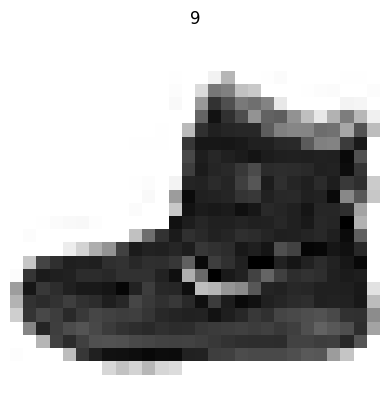

In [7]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='binary')
plt.axis('off')
plt.title(y_train[0])
plt.show()

In [ ]:
import numpy as np
np.unique(y_train)

In [ ]:
# 다중 분류(multi class, 단일 정답)(= 0~9중에 1개를 맞추는 것)
# 마지막 출력층 softmax = 모든 출력의 합이 1, 확률 분포 형태 
# 각 클래스별로 확률값(Ex: 마지막 10개의 결과를 출력하는데, 각각의 결과 안에는 0일때 확률 몇프로, 1일때 확률 몇프로 등... 이중에 확률이 가장 높은 class가 정답)
# 은닉층 만들기
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(28, 28)) )
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation='relu'))
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax')) # 마지막 확률분포

In [ ]:
model.summary()

In [ ]:
784*300

In [ ]:
model.layers

In [ ]:
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'sgd',
    metrics = ['accuracy']
)

In [ ]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_valid, y_valid))

# [5교시]

In [ ]:
predict = model.predict(x_test[:5])
print(predict.shape)

In [ ]:
print(x_test.shape)

In [ ]:
np.argmax(predict, axis= 1)

In [ ]:
y_test[:5]

In [ ]:
predict = model.predict(x_test)

In [ ]:
sum(np.argmax(predict,axis=1) == y_test) / len(y_test)

# [6교시]

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, np.argmax(predict, axis=1)))

In [ ]:
history.history.keys()

In [ ]:
# x축은 range(30)
# y축은 loss, val_loss
# plt.plot


In [ ]:
import matplotlib.pyplot as plt

# 학습 기록에서 손실 값 꺼내기
loss = history.history['loss']
val_loss = history.history['val_loss']

# x축: 0~29 (30 epochs)
epochs = range(30)

plt.figure(figsize=(8,6))
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# 학습 기록에서 손실 값 꺼내기
loss = history.history['loss']
val_loss = history.history['val_loss']

# x축: 0~29 (30 epochs)
epochs = range(30)

plt.figure(figsize=(8,6))
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# [7교시]

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(42)

In [ ]:
layer_no_act = []
for i in range(100):
    layer_no_act.append(nn.Linear(4,4))
layer_no_act

In [ ]:
# 100개의 리스트를 만들어 순차적으로 연결
layer_no_act = []
for i in range(100):
    layer_no_act.append(nn.Linear(4,4))
# 딥러닝 객체로 담는다
deep_no_activation = nn.Sequential(*layer_no_act)
# 1층
single_layer = nn.Linear(4,4)
# 데이터
x_test = torch.randn(1, 4)
# 초기화
w_ = torch.eye(4)
b_ = torch.zeros(4)

for layer in layer_no_act:
    w_ = layer.weight @ w_
    b_ = layer.weight @ b_

output_ = x_test @ w_.T + b_

with torch.no_grad():
    output_100 = deep_no_activation(x_test)

output_100, output_

In [ ]:
# 기울기 소실

torch.manual_seed(42)
class SigmoidNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 8)   # 데이터 입력 할 떄 처음만난 레이어 (= Hidden layer)
        self.layer2 = nn.Linear(8, 8)   # 그다음 레이어는 8개, 10개, 100개 상관 없다!
        self.layer3 = nn.Linear(8, 8)   # 사용자가 직접 조절할 수 있는 값  
        self.layer4 = nn.Linear(8, 8)
        self.layer5 = nn.Linear(8, 1)
    def forward(self, x):
        x = torch.sigmoid(self.layer1(x))   # 은닉층 1번째
        x = torch.sigmoid(self.layer2(x))   # 은닉층 2번째
        x = torch.sigmoid(self.layer3(x))   # 은닉층 3번쨰
        x = torch.sigmoid(self.layer4(x))   # 은닉층 4번째
        x = self.layer5(x)
        return x
    
sigmoid_net = SigmoidNet()

In [ ]:
sigmoid_net

# [8교시]

In [ ]:
x_input = torch.randn(1, 4)
y_target = torch.tensor([[1.0]])
output = sigmoid_net(x_input)
loss = (y_target - output)**2
loss.backward() # 각 계산마다 자동으로 미분을 호출

In [ ]:
print(f"{'레이어':>10} | {'기울기 평균 크기':>20}")

In [ ]:
for name, param in sigmoid_net.named_parameters():
    print(name, param.grad.abs().mean())
    break

In [ ]:
for name, param in sigmoid_net.named_parameters():
    grad_magnitude = param.grad.abs().mean().item()
    status = "소실" if grad_magnitude <0.001 else "보통" if grad_magnitude > 0.01 else '양호'
    print(name, grad_magnitude, status)

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(42)

class ReLUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 8)   # 데이터 입력 할 떄 처음만난 레이어 (= Hidden layer)
        self.layer2 = nn.Linear(8, 8)   # 그다음 레이어는 8개, 10개, 100개 상관 없다!
        self.layer3 = nn.Linear(8, 8)   # 사용자가 직접 조절할 수 있는 값  
        self.layer4 = nn.Linear(8, 8)
        self.layer5 = nn.Linear(8, 1)
        self.leaky_relu = nn.LeakyReLU()

    def forward(self, x):
        x = torch.sigmoid(self.layer1(x))   # 은닉층 1번째
        x = torch.sigmoid(self.layer2(x))   # 은닉층 2번째
        x = torch.sigmoid(self.layer3(x))   # 은닉층 3번쨰
        x = torch.sigmoid(self.layer4(x))   # 은닉층 4번째
        x = self.layer5(x)
        return x

# 네트워크 인스턴스 생성
reluNet = ReLUNet()

# 입력과 타깃
x_input = torch.randn(1, 4)
y_target = torch.tensor([[1.0]])

# 순전파
output = reluNet(x_input)
loss = (y_target - output)**2

# 역전파
loss.backward() # 각 계산마다 자동으로 미분을 호출

# 기울기 출력
for name, param in reluNet.named_parameters():
    grad_magnitude = param.grad.abs().mean().item()
    status = "소실" if grad_magnitude < 0.001 else "보통" if grad_magnitude > 0.01 else "양호"
    print(name, grad_magnitude, status)
